# 3 — Cheat Sheet: Univariate Time Series in Python
Quick, runnable reference. Each section is self-contained — copy the snippet you need.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, arma_order_select_ic
from statsmodels.tsa.arima.model import ARIMA
import pmdarima as pm
from pmdarima.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import math


## Identification rules (memorize)
| Pattern | Model |
|---|---|
| PACF cuts off after lag $p$, ACF decays | AR($p$) |
| ACF cuts off after lag $q$, PACF decays | MA($q$) |
| Both ACF & PACF decay/taper | ARMA($p,q$) |
| ACF decays very slowly (near 1 for many lags) | unit root / trend → difference |
| ACF has a repeating spike every $s$ lags | seasonality of period $s$ → seasonal-difference at lag $s$ |


## Stationarity via roots (AR polynomial)

In [2]:
arparams = np.array([0.5])
ar = np.r_[1, -arparams]                 # (1 - phi_1 B - ... )
proc = sm.tsa.ArmaProcess(ar)
print('Roots:', proc.arroots)
print('Stationary:', proc.isstationary)   # all |root| > 1 required
# Manual check for complex conjugate roots a +/- bi: magnitude = sqrt(a**2 + b**2) > 1


Roots: [2.]
Stationary: True


## Invertibility via roots (MA polynomial)

In [3]:
maparams = np.array([0.8])
ma = np.r_[1, -maparams]
proc = sm.tsa.ArmaProcess(ma=ma)
print('Roots:', proc.maroots)
print('Invertible:', proc.isinvertible)   # all |root| > 1 required


Roots: [1.25]
Invertible: True


## Simulate a process with known ground truth (for practice / teaching)

In [4]:
arparams = np.array([1.2, -0.6])   # AR(2)
maparams  = np.array([0.5])          # MA(1)
ar = np.r_[1, -arparams]
ma = np.r_[1, -maparams]
proc = sm.tsa.ArmaProcess(ar=ar, ma=ma)
print('AR stationary:', proc.isstationary, '| MA invertible:', proc.isinvertible)
y = proc.generate_sample(nsample=200)


AR stationary: True | MA invertible: True


## Visual inspection: realization + ACF + PACF

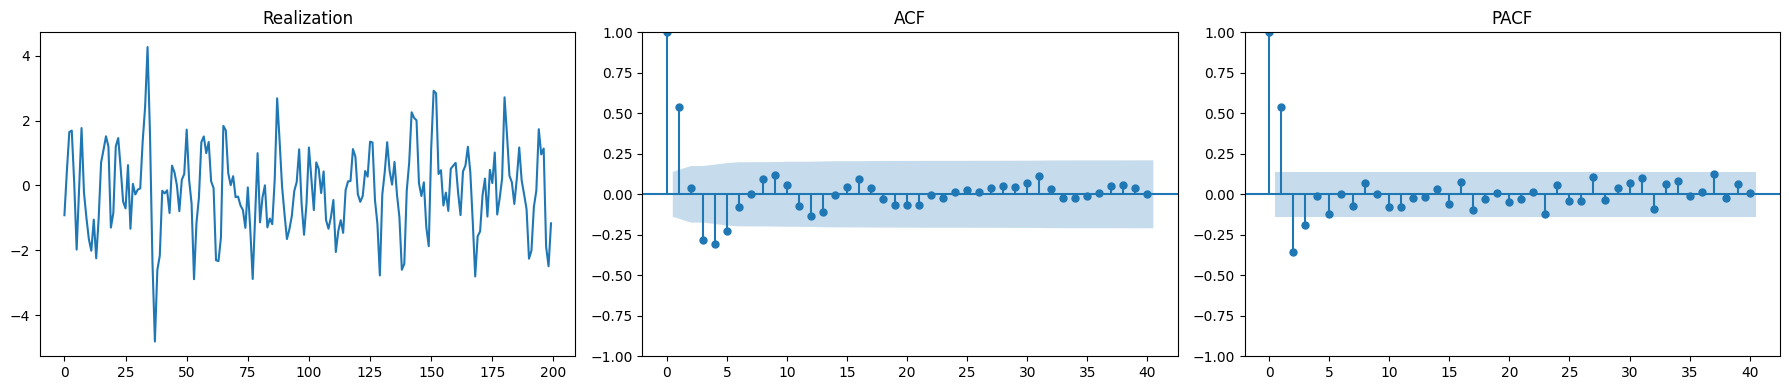

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
ax[0].plot(y); ax[0].set_title('Realization')
plot_acf(y, alpha=0.05, lags=40, ax=ax[1]); ax[1].set_title('ACF')
plot_pacf(y, alpha=0.05, lags=40, ax=ax[2]); ax[2].set_title('PACF')
plt.tight_layout(); plt.show()


## Augmented Dickey-Fuller test (unit root / trend)

In [6]:
result = adfuller(y, maxlag=25, regression='c')
print('ADF statistic:', result[0])
print('p-value:', result[1])
print('5% critical value:', result[4]['5%'])
# H0: unit root present (non-stationary). p < 0.05  -> reject H0 -> treat as stationary / no trend.


ADF statistic: -9.705386572969209
p-value: 1.0452636722618162e-16
5% critical value: -2.8763259091636213


/tmp/ipykernel_618/1937697255.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(y, maxlag=25, regression='c')


## Order selection via AIC/BIC grid search (statsmodels)

In [7]:
order_search = arma_order_select_ic(y=y, max_ar=4, max_ma=2, ic=['aic', 'bic'], trend='n')
print('AIC order:', order_search.aic_min_order, '| AIC:', round(order_search.aic.min().min(), 3))
print('BIC order:', order_search.bic_min_order, '| BIC:', round(order_search.bic.min().min(), 3))


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


AIC order: (np.int64(3), np.int64(0)) | AIC: 577.215
BIC order: (np.int64(3), np.int64(0)) | BIC: 590.408


## Fit an ARIMA(p, d, q) model

In [8]:
model = ARIMA(y, order=(2, 0, 1), enforce_stationarity=True, enforce_invertibility=True).fit()
print(model.summary())
# Read: coefficient p-values (drop terms with CI containing 0), AIC/BIC,
#       Ljung-Box (want high p -> no residual autocorrelation),
#       Jarque-Bera (want high p -> normal residuals),
#       Heteroskedasticity (want high p -> constant variance)


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  200
Model:                 ARIMA(2, 0, 1)   Log Likelihood                -283.136
Date:                Fri, 28 Aug 2026   AIC                            576.272
Time:                        20:27:18   BIC                            592.763
Sample:                             0   HQIC                           582.946
                                - 200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1479      0.081     -1.815      0.070      -0.308       0.012
ar.L1          1.1630      0.113     10.332      0.000       0.942       1.384
ar.L2         -0.5928      0.062     -9.532      0.0

## Test-forecast (hold out last h points) + error

In [9]:
h = 5
n = len(y)
df_pred = model.get_prediction(start=n - h, end=n - 1).summary_frame(alpha=0.05)
actuals = y[n - h:]
ase = np.mean((df_pred['mean'].values - actuals) ** 2)
print('Average Squared Error:', ase)
df_pred


Average Squared Error: 1.2005644174795358


y,mean,mean_se,mean_ci_lower,mean_ci_upper
0,1.355416,0.99482,-0.594396,3.305228
1,0.224581,0.99482,-1.725231,2.174392
2,0.226381,0.99482,-1.723431,2.176192
3,-1.854000,0.99482,-3.803812,0.095812
4,-1.517087,0.99482,-3.466899,0.432725


## Forecast beyond observed data with confidence interval

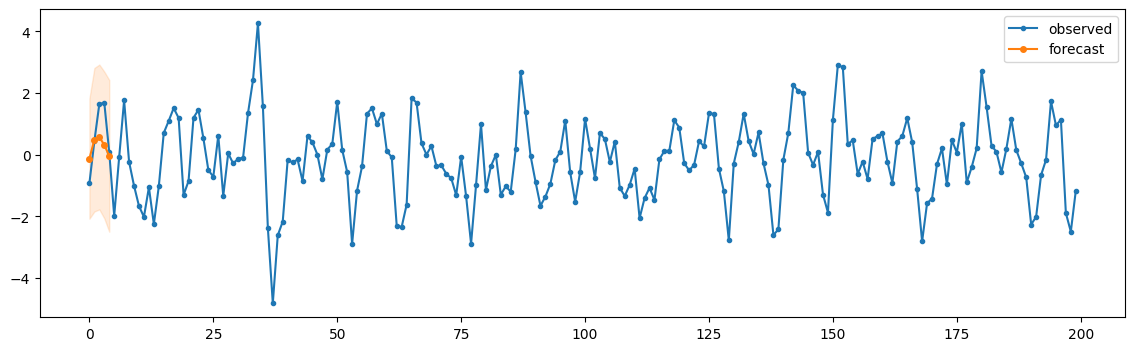

In [10]:
h = 5
n = len(y)
df_forecast = model.get_prediction(start=n, end=n + h - 1).summary_frame(alpha=0.05)
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(range(n), y, marker='o', ms=3, label='observed')
ax.plot(df_forecast.index, df_forecast['mean'], marker='o', ms=4, color='C1', label='forecast')
ax.fill_between(df_forecast.index, df_forecast['mean_ci_lower'], df_forecast['mean_ci_upper'],
                 color='C1', alpha=0.15)
ax.legend(); plt.show()


## Differencing (manual) and re-testing for stationarity

In [11]:
first_diff = np.diff(y, n=1)                 # first-order difference
adf_p = adfuller(first_diff, maxlag=25, regression='c')[1]
print('ADF p-value after 1st difference:', adf_p)
# If still > 0.05, difference again (rare beyond d=2 for most business/economic series)


ADF p-value after 1st difference: 3.837514696287698e-09


/tmp/ipykernel_618/3085009192.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_p = adfuller(first_diff, maxlag=25, regression='c')[1]


## Seasonal differencing (pmdarima)

In [12]:
# T = seasonal period identified from a repeating ACF spike, e.g. 12 for monthly data
# series_seasonal = pm.utils.diff(y, lag=12)
# Then re-check ADF on series_seasonal; if still non-stationary, difference again with pm.utils.diff(series_seasonal)


## Automatic order selection incl. differencing (pmdarima.auto_arima)

In [13]:
# Non-seasonal:
# auto_model = pm.auto_arima(y, seasonal=False, error_action='ignore', suppress_warnings=True, test='adf', trace=True)

# Seasonal (period m), searches (p,d,q)(P,D,Q)[m]:
# auto_model = pm.auto_arima(y, seasonal=True, m=12, error_action='ignore', suppress_warnings=True, test='adf', trace=True)

# print(auto_model.summary())


## Train/test split + forecast + RMSE (pmdarima style)

In [14]:
# train, test = train_test_split(y, train_size=0.9)
# fitted = pm.auto_arima(train, seasonal=False, error_action='ignore', suppress_warnings=True, test='adf')
# preds, conf_int = fitted.predict(n_periods=len(test), return_conf_int=True)
# rmse = math.sqrt(mean_squared_error(test, preds))


## Resampling (change time frequency)

In [15]:
# data.resample('7D').mean()   # weekly downsample
# data.resample('M').mean()    # monthly downsample
# data.resample('Y').mean()    # yearly downsample


## Shifting (lag features)

In [16]:
# data['lag_1'] = data['Open'].shift(1)
# data['lag_1'] = data['Open'].shift(1, fill_value=data['Open'].mean())  # caution: biases the first row toward the unconditional mean


## Baseline 1: optimized persistence forecasting

In [17]:
def persistence_rmse_curve(train, test, max_p=24):
    scores = []
    for p in range(1, max_p + 1):
        history = list(train)
        preds = []
        for i in range(len(test)):
            preds.append(history[-p])
            history.append(test.iloc[i] if hasattr(test, 'iloc') else test[i])
        scores.append(math.sqrt(mean_squared_error(test, preds)))
    return scores

# scores = persistence_rmse_curve(train, test, max_p=24)
# best_p = int(np.argmin(scores)) + 1


## Baseline 2: rolling-window forecasting

In [18]:
def rolling_rmse_curve(train, test, max_w=24):
    scores = []
    for w in range(1, max_w + 1):
        history = list(train)
        preds = []
        for i in range(len(test)):
            preds.append(np.mean(history[-w:]))
            history.append(test.iloc[i] if hasattr(test, 'iloc') else test[i])
        scores.append(math.sqrt(mean_squared_error(test, preds)))
    return scores

# scores = rolling_rmse_curve(train, test, max_w=24)
# best_w = int(np.argmin(scores)) + 1


## Diagnostic interpretation quick table
| Test in `.summary()` | H0 | Want | If violated |
|---|---|---|---|
| Ljung-Box (Prob(Q)) | no autocorrelation in residuals | high p-value | add AR/MA terms, reconsider order |
| Jarque-Bera (Prob(JB)) | residuals are normal | high p-value | inference/CI may be unreliable; consider transform |
| Heteroskedasticity (Prob(H)) | residual variance constant | high p-value | consider GARCH-family / variance-stabilizing transform |
| Skew | — | in [-0.5, 0.5] | asymmetric shocks; investigate outliers |
| Kurtosis | — | near 3 | heavy tails (>7 = high) → outlier-robust methods |


## Common pitfalls checklist
- [ ] Did you check stationarity *before* interpreting ACF/PACF for order selection?
- [ ] Did you use `enforce_stationarity=True, enforce_invertibility=True` and actually read any resulting warning?
- [ ] Did AIC and BIC disagree? If so, did you check coefficient significance before picking the higher-order model?
- [ ] Did you evaluate on a genuine **held-out** period, not just in-sample AIC/BIC?
- [ ] Did you compare against a naive persistence/rolling-window baseline?
- [ ] Are you forecasting **prices** (near-random-walk, hard) vs. **returns/differences** (more stationary, often easier)?
- [ ] Did you widen `maxlag` in the ADF test if the ACF shows slow decay far out?
